In [15]:
import os
import numpy as np
import pandas as pd

# ============================================================
# 0) 設定
# ============================================================
NPZ_PATH = "dataset_irregular.npz"
L_GRID   = 256
SEED     = 0
N_BASE   = 120     # 基準波形に使う学習サイクル数（任意に変更）
DEN_EPS  = 1e-6    # NWの分母が小さい点を欠損扱いにする閾値

rng = np.random.default_rng(SEED)

# ============================================================
# 1) 読み込み（ユーザー提示の形式）
# ============================================================
d = np.load(NPZ_PATH, allow_pickle=True)
train_list = d["train_list"].tolist()
test_list  = d["test_list"].tolist()

def group_by_cycle(sample_list):
    """
    sample_list を cycle_id ごとにまとめて dict にする
    dict[cid] = (deg_array, y_array, label)
    """
    arr = np.asarray(sample_list, dtype=object)
    cid = arr[:,0].astype(int)
    deg = arr[:,1].astype(float)
    y   = arr[:,2].astype(float)
    lab = arr[:,3].astype(int)

    order = np.lexsort((deg, cid))
    cid, deg, y, lab = cid[order], deg[order], y[order], lab[order]

    cycles = {}
    start = 0
    while start < len(cid):
        c = int(cid[start])
        end = start
        while end < len(cid) and int(cid[end]) == c:
            end += 1
        cycles[c] = (deg[start:end], y[start:end], int(lab[start]))
        start = end
    return cycles

train_cycles = group_by_cycle(train_list)
test_cycles  = group_by_cycle(test_list)


In [16]:

# ============================================================
# 2) 高速NW（円環：ビン化 + FFT円環畳み込み）
# ============================================================
def bin_sum_on_circle(deg, y, Lbin):
    deg = np.asarray(deg, float)
    y   = np.asarray(y, float)
    idx = np.floor(deg / 360.0 * Lbin).astype(int)
    idx = np.clip(idx, 0, Lbin-1)
    num = np.zeros(Lbin, dtype=float)
    den = np.zeros(Lbin, dtype=float)
    np.add.at(num, idx, y)
    np.add.at(den, idx, 1.0)
    return num, den

def gaussian_kernel_on_circle(Lbin, h_deg):
    delta = 360.0 / Lbin
    k = np.arange(Lbin, dtype=float)
    kdist = np.minimum(k, Lbin - k)     # 円環距離（ビン単位）
    d_deg = kdist * delta
    ker = np.exp(-0.5 * (d_deg / h_deg)**2)
    ker = ker / (ker.sum() + 1e-12)     # 正規化
    return ker

def estimate_h_deg_from_deg(deg, Lbin):
    """
    h_deg を手で決めたくない場合の自動推奨値
    - 角度差分（円環）の中央値 med をとって 2*med を帯域にする
    - 最低でも 1ビン幅 (360/Lbin) は確保
    """
    deg = np.sort(np.asarray(deg, float))
    if len(deg) < 3:
        return 360.0 / Lbin
    dif  = np.diff(deg)
    wrap = (deg[0] + 360.0) - deg[-1]
    dif  = np.concatenate([dif, [wrap]])
    med  = float(np.median(dif))
    return float(max(360.0 / Lbin, 2.0 * med))

def nw_fast_on_circle(deg, y, Lbin, h_deg=None, den_eps=DEN_EPS):
    num_bin, den_bin = bin_sum_on_circle(deg, y, Lbin)
    if h_deg is None:
        h_deg = estimate_h_deg_from_deg(deg, Lbin)
    ker = gaussian_kernel_on_circle(Lbin, h_deg)

    F_num = np.fft.fft(num_bin)
    F_den = np.fft.fft(den_bin)
    F_ker = np.fft.fft(ker)

    num_s = np.fft.ifft(F_num * F_ker).real
    den_s = np.fft.ifft(F_den * F_ker).real

    x = np.full(Lbin, np.nan, float)
    m = den_s > den_eps
    x[m] = num_s[m] / den_s[m]
    return x, m.astype(np.int8), den_s, float(h_deg)

# ============================================================
# 3) 基準波形（参照波形）の作成：学習サイクルをN_BASE本選ぶ → 点を連結 → NW
# ============================================================
train_ids = np.array(sorted(train_cycles.keys()), dtype=int)
rng.shuffle(train_ids)
base_ids = train_ids[:min(N_BASE, len(train_ids))]

deg_ref = np.concatenate([train_cycles[c][0] for c in base_ids])
y_ref   = np.concatenate([train_cycles[c][1] for c in base_ids])

ref_grid, ref_m, ref_den, h_deg_ref = nw_fast_on_circle(deg_ref, y_ref, L_GRID, h_deg=None)

# ============================================================
# 4) 位相シフト推定（FFT相関：欠損対応の重み付き相関）
#   shift_bin = 「x に roll(shift_bin) を適用すると ref に最も合う」定義
# ============================================================
def estimate_phase_shift_by_weighted_corr_fft(x, ref, min_overlap=64):
    x   = np.asarray(x, float)
    ref = np.asarray(ref, float)

    w = np.isfinite(x).astype(float)
    v = np.isfinite(ref).astype(float)

    x0 = np.nan_to_num(x,   nan=0.0)
    r0 = np.nan_to_num(ref, nan=0.0)

    def cc(a, b):
        # circular cross-correlation: ifft(conj(fft(a))*fft(b))
        return np.fft.ifft(np.conj(np.fft.fft(a)) * np.fft.fft(b)).real

    overlap = cc(w, v)            # sum w_shift * v
    sum_x   = cc(x0, v)           # sum x_shift * v
    sum_x2  = cc(x0*x0, v)        # sum x_shift^2 * v
    sum_xr  = cc(x0, r0*v)        # sum x_shift * (ref*v)

    Nv = v.sum()
    if Nv < 2:
        return 0, np.full(len(x), -np.inf)

    mean_r = (r0*v).sum() / Nv
    var_r  = ( (r0*r0*v).sum() / Nv ) - mean_r**2
    var_r  = max(var_r, 1e-12)

    corr = np.full(len(x), -np.inf, float)
    ok = overlap >= float(min_overlap)
    if np.any(ok):
        mx  = sum_x[ok] / overlap[ok]
        vx  = (sum_x2[ok] / overlap[ok]) - mx**2
        vx  = np.maximum(vx, 1e-12)
        cov = (sum_xr[ok] / overlap[ok]) - mx*mean_r
        corr[ok] = cov / np.sqrt(vx * var_r)

    s = int(np.nanargmax(corr))
    return s, corr

# ============================================================
# 5) 形状差・スパイク・周波数差に使う補助
# ============================================================
def zscore_with_mask(x, m):
    x = np.asarray(x, float)
    m = np.asarray(m, bool)
    if m.sum() < 3:
        return np.full_like(x, np.nan), np.nan, np.nan
    mu = float(np.mean(x[m]))
    sd = float(np.std(x[m]))
    if not np.isfinite(sd) or sd < 1e-12:
        sd = 1e-12
    z = (x - mu) / sd
    z[~m] = np.nan
    return z, mu, sd

def fft_band_power_ratios(x, bands, exclude_dc=True):
    x0 = np.nan_to_num(np.asarray(x, float), nan=0.0)
    F  = np.fft.rfft(x0)
    P  = (F.real*F.real + F.imag*F.imag)  # power
    if exclude_dc and len(P) > 0:
        P = P.copy()
        P[0] = 0.0
    total = float(P.sum()) + 1e-12
    out = {}
    for name, (k0, k1) in bands.items():
        k0 = max(0, int(k0))
        k1 = min(len(P)-1, int(k1))
        out[name] = float(P[k0:k1+1].sum() / total)
    return out, P

def cosine_sim(a, b, eps=1e-12):
    a = np.asarray(a, float).ravel()
    b = np.asarray(b, float).ravel()
    na = float(np.linalg.norm(a))
    nb = float(np.linalg.norm(b))
    if na < eps or nb < eps:
        return np.nan
    return float(a.dot(b) / (na*nb))

BANDS = {
    "low_1_3": (1, 3),
    "mid_4_16": (4, 16),
    "high_17_64": (17, 64),
    "ultra_65_128": (65, 128),
}

# ============================================================
# 6) 1サイクルの特徴量
# ============================================================
def features_one_cycle(deg, y, label, ref_grid, h_deg_shared):
    # 等間隔化
    x_grid, m, den_s, h_used = nw_fast_on_circle(deg, y, L_GRID, h_deg=h_deg_shared)

    # 位相（横ずれ）
    shift_bin, corr = estimate_phase_shift_by_weighted_corr_fft(x_grid, ref_grid, min_overlap=64)
    shift_deg = shift_bin * 360.0 / L_GRID

    # 位置合わせ（x を roll して ref に合わせる）
    x_al = np.roll(x_grid, shift_bin)
    ok   = np.isfinite(x_al) & np.isfinite(ref_grid)
    n_ok = int(ok.sum())

    # ①上下シフト（平均との差：オフセット）
    offset_mean = float(np.mean((x_al - ref_grid)[ok])) if n_ok >= 3 else np.nan

    # ③形状変化（標準化後の RMS 差）
    zx, mu_x, sd_x = zscore_with_mask(x_al, ok)
    zr, mu_r, sd_r = zscore_with_mask(ref_grid, ok)
    shape_rms = float(np.sqrt(np.mean((zx[ok] - zr[ok])**2))) if n_ok >= 3 else np.nan

    # ⑤スパイク（局所的な最大差）
    spike_abs  = float(np.nanmax(np.abs((x_al - ref_grid) - offset_mean))) if np.isfinite(offset_mean) else np.nan
    spike_zmax = float(np.nanmax(np.abs(zx - zr))) if n_ok >= 3 else np.nan

    # ④周波数成分の変化（標準化後FFTの帯域パワー比の差 + スペクトル類似度）
    band_x, P_x = fft_band_power_ratios(zx, BANDS)
    band_r, P_r = fft_band_power_ratios(zr, BANDS)

    out = {
        "cycle_id": None,
        "label": int(label),

        # 波形全体の平均（絶対値としての平均）
        "mean": float(np.nanmean(x_grid)),

        # ①上下シフト（参照との差分としての平均）
        "offset_mean": offset_mean,

        # ②横ずれ（位相）
        "phase_shift_bin": int(shift_bin),
        "phase_shift_deg": float(shift_deg),
        "phase_corr_max": float(np.nanmax(corr)),

        # ③形状差
        "shape_rms": shape_rms,

        # ⑤スパイク
        "spike_abs": spike_abs,
        "spike_zmax": spike_zmax,

        # ④周波数差（スペクトル）
        "spec_cosine": cosine_sim(P_x[1:], P_r[1:]),
    }
    for k in BANDS.keys():
        out[f"band_{k}_x"]    = band_x[k]
        out[f"band_{k}_ref"]  = band_r[k]
        out[f"band_{k}_diff"] = band_x[k] - band_r[k]
    return out


In [ ]:

# ============================================================
# 7) 全サイクルに適用して DataFrame 化
#   方針：h_deg を参照波形作成時に推定した値で「全サイクル共通」にする（挙動が安定）
# ============================================================
def build_features_df(cycles_dict, ref_grid, h_deg_shared):
    rows = []
    for cid, (deg, y, lab) in cycles_dict.items():
        f = features_one_cycle(deg, y, lab, ref_grid, h_deg_shared=h_deg_shared)
        f["cycle_id"] = int(cid)
        rows.append(f)
    return pd.DataFrame(rows).sort_values("cycle_id").reset_index(drop=True)

train_df = build_features_df(train_cycles, ref_grid, h_deg_shared=h_deg_ref)
test_df  = build_features_df(test_cycles,  ref_grid, h_deg_shared=h_deg_ref)

print("h_deg_ref:", h_deg_ref)
print("train_df shape:", train_df.shape, "test_df shape:", test_df.shape)

# 必要なら保存
# train_df.to_csv("train_features.csv", index=False)
# test_df.to_csv("test_features.csv", index=False)

test_df

h_deg_ref: 1.40625
train_df shape: (700, 23) test_df shape: (1020, 23)


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ============================================================
# 0) PCAに入れる特徴量を選ぶ
#   - MSPCは「多変量の形状変化」を見るので、基本は diff 系と主要スカラーを入れる
#   - train_df は正常のみ想定（あなたのnpzがそういう構成）
# ============================================================
base_cols = [
    "mean",
    "offset_mean",
    "phase_shift_deg",
    "phase_corr_max",
    "shape_rms",
    "spike_abs",
    "spike_zmax",
    "spec_cosine",
]
band_diff_cols = [c for c in train_df.columns if c.startswith("band_") and c.endswith("_diff")]

feat_cols = [c for c in base_cols + band_diff_cols if c in train_df.columns]

# ============================================================
# 1) 前処理（欠損埋め→標準化）と PCA 学習
# ============================================================
Xtr = train_df[feat_cols].to_numpy()
Xte = test_df[feat_cols].to_numpy()

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

Xtr_i = imputer.fit_transform(Xtr)
Xte_i = imputer.transform(Xte)

Xtr_z = scaler.fit_transform(Xtr_i)
Xte_z = scaler.transform(Xte_i)

# PCA：累積寄与率が 0.90 を超える最小次元を採用
pca_full = PCA(svd_solver="full", random_state=0)
pca_full.fit(Xtr_z)

cum = np.cumsum(pca_full.explained_variance_ratio_)
k = int(np.searchsorted(cum, 0.90) + 1)
k = max(2, k)  # 可視化のため最低2次元

pca = PCA(n_components=k, svd_solver="full", random_state=0)
Ttr = pca.fit_transform(Xtr_z)   # scores
Tte = pca.transform(Xte_z)

# ============================================================
# 2) MSPC スコア（T^2, Q）を計算
#   - T^2 = Σ_j (t_j^2 / λ_j)
#   - Q   = ||x - x_hat||^2 （標準化空間での残差二乗和）
# ============================================================
lam = pca.explained_variance_          # λ_j
T2_tr = np.sum((Ttr**2) / (lam[None, :] + 1e-12), axis=1)
T2_te = np.sum((Tte**2) / (lam[None, :] + 1e-12), axis=1)

Xtr_hat = pca.inverse_transform(Ttr)
Xte_hat = pca.inverse_transform(Tte)
Q_tr = np.sum((Xtr_z - Xtr_hat)**2, axis=1)
Q_te = np.sum((Xte_z - Xte_hat)**2, axis=1)

# しきい値：学習（正常）から経験分位点で決める（実務で堅い）
ALPHA = 0.99
thr_T2 = float(np.quantile(T2_tr, ALPHA))
thr_Q  = float(np.quantile(Q_tr,  ALPHA))

# まとめDF
df_tr = train_df[["cycle_id","label"]].copy()
df_te = test_df[["cycle_id","label"]].copy()

df_tr["T2"] = T2_tr
df_tr["Q"]  = Q_tr
df_te["T2"] = T2_te
df_te["Q"]  = Q_te

for j in range(min(5, k)):
    df_tr[f"PC{j+1}"] = Ttr[:, j]
    df_te[f"PC{j+1}"] = Tte[:, j]

# ============================================================
# 3) 背景色分け（ラベル連続区間ごと）
# ============================================================
def add_label_background(ax, x, labels, alpha=0.10):
    x = np.asarray(x)
    labels = np.asarray(labels)
    cmap = plt.get_cmap("tab10")

    if len(x) == 0:
        return

    start = 0
    for i in range(1, len(x)):
        if labels[i] != labels[i-1]:
            lab = int(labels[i-1])
            ax.axvspan(x[start], x[i-1], color=cmap(lab % 10), alpha=alpha, lw=0)
            start = i
    lab = int(labels[-1])
    ax.axvspan(x[start], x[-1], color=cmap(lab % 10), alpha=alpha, lw=0)


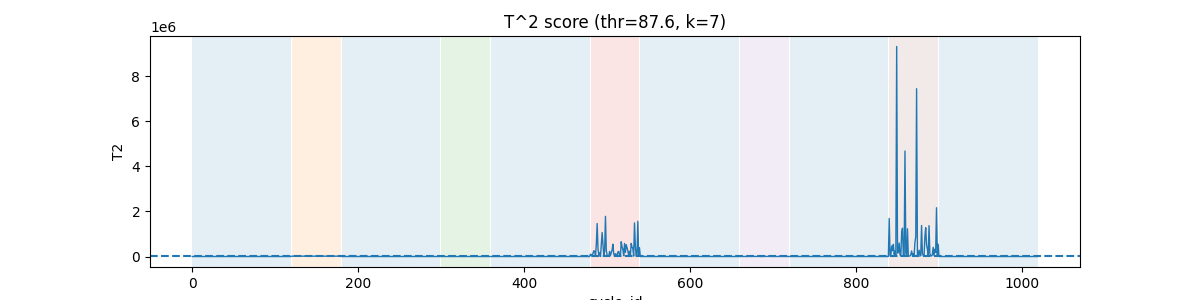

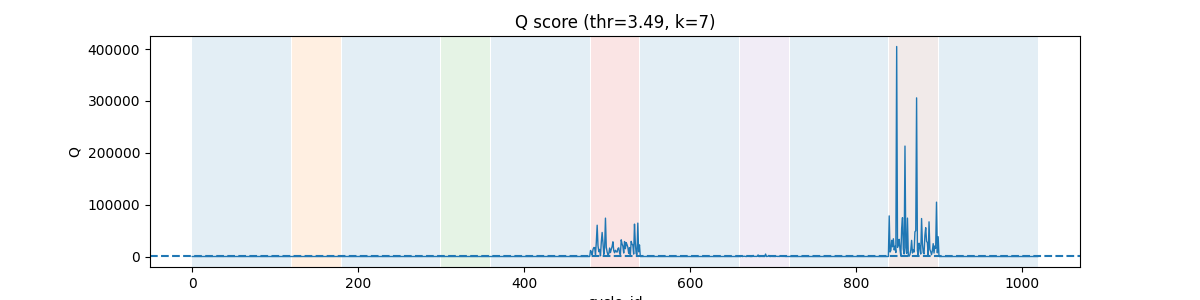

In [19]:
%matplotlib widget
# ============================================================
# 4) MSPCスコア時系列（背景＝ラベル）
# ============================================================
x = df_te["cycle_id"].to_numpy()
lab = df_te["label"].to_numpy()

fig, ax = plt.subplots(figsize=(12, 3))
add_label_background(ax, x, lab, alpha=0.12)
ax.plot(x, df_te["T2"].to_numpy(), lw=1)
ax.axhline(thr_T2, ls="--")
ax.set_title(f"T^2 score (thr={thr_T2:.3g}, k={k})")
ax.set_xlabel("cycle_id")
ax.set_ylabel("T2")
plt.show()

fig, ax = plt.subplots(figsize=(12, 3))
add_label_background(ax, x, lab, alpha=0.12)
ax.plot(x, df_te["Q"].to_numpy(), lw=1)
ax.axhline(thr_Q, ls="--")
ax.set_title(f"Q score (thr={thr_Q:.3g}, k={k})")
ax.set_xlabel("cycle_id")
ax.set_ylabel("Q")
plt.show()


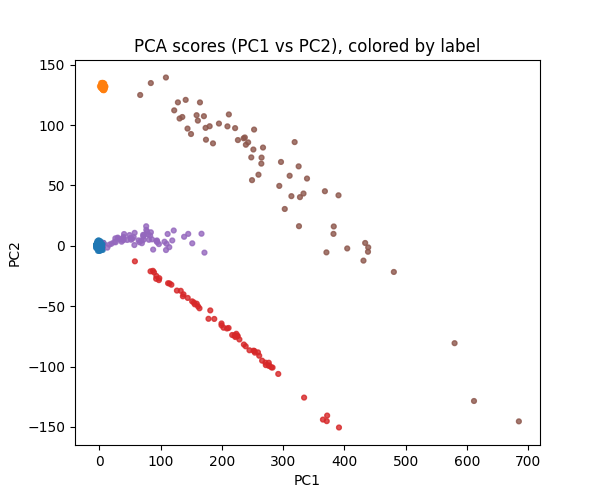

In [20]:

# ============================================================
# 5) サンプル点プロット（PC1-PC2、色＝ラベル）
# ============================================================
cmap = plt.get_cmap("tab10")
colors = cmap((df_te["label"].to_numpy() % 10).astype(int))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_te["PC1"], df_te["PC2"], s=12, c=colors, alpha=0.8)
ax.set_title("PCA scores (PC1 vs PC2), colored by label")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.show()


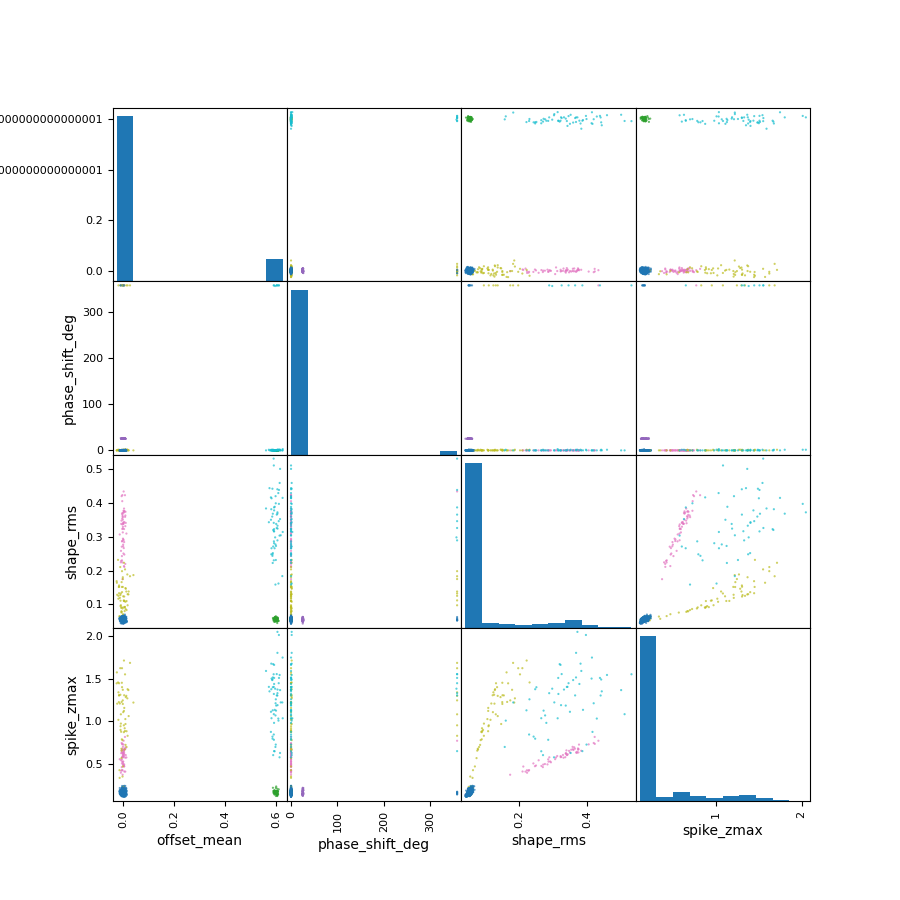

In [21]:

# ============================================================
# 6) pairplot相当：散布図行列（scatter_matrix）
#    可視化が重いので、表示する特徴量は少なめ推奨
# ============================================================
from pandas.plotting import scatter_matrix

pair_cols = ["offset_mean","phase_shift_deg","shape_rms","spike_zmax"]
pair_cols = [c for c in pair_cols if c in df_te.columns or c in test_df.columns]

df_pair = df_te.merge(test_df[["cycle_id"] + feat_cols], on="cycle_id", how="left")

cvals = (df_pair["label"].to_numpy() % 10).astype(int)
fig = scatter_matrix(
    df_pair[pair_cols],
    figsize=(9, 9),
    diagonal="hist",
    c=cvals,
    cmap="tab10",
    s=10,
    alpha=0.7,
)
plt.suptitle("Scatter-matrix (pairplot equivalent), colored by label", y=1.02)
plt.show()